# 导入数据

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

model_name = "FVs_SigLIP"

npz_path = f"./aligned_features_drvalid/aligned_drvalid_{model_name}.npz"
meta_path = f"./aligned_features_drvalid/aligned_drvalid_{model_name}_metadata.csv"

data = np.load(npz_path, allow_pickle=True)
X = data["X"]

meta_df = pd.read_csv(meta_path)

print("X:", X.shape)
print("metadata:", meta_df.shape)
print(meta_df.head())
print(meta_df["eye_DR_Level"].value_counts().sort_index())

X: (1189, 1152)
metadata: (1189, 12)
   patient_id image_id                           image_path  Overall quality  \
0           1     1_l1  \regular-fundus-training\1\1_l1.jpg                0   
1           1     1_l2  \regular-fundus-training\1\1_l2.jpg                0   
2           1     1_r1  \regular-fundus-training\1\1_r1.jpg                0   
3           1     1_r2  \regular-fundus-training\1\1_r2.jpg                0   
4           2     2_l1  \regular-fundus-training\2\2_l1.jpg                0   

   left_eye_DR_Level  right_eye_DR_Level  patient_DR_Level  Clarity  \
0                0.0                 NaN                 0        8   
1                0.0                 NaN                 0        8   
2                NaN                 0.0                 0        8   
3                NaN                 0.0                 0       10   
4                2.0                 NaN                 2       10   

   Field definition  Artifact eye  eye_DR_Level  
0    

# PCA

方差贡献率
累计贡献率

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 标准化
X_raw = X.copy() 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# PCA
n_components = 50
pca = PCA(n_components=n_components, random_state=0)
Z = pca.fit_transform(X_scaled)

print("PCA result:", Z.shape)
print("Explained variance ratio:")
print(pca.explained_variance_ratio_[:10])
print("Cumulative explained variance:")
print(np.cumsum(pca.explained_variance_ratio_)[:10])

PCA result: (1189, 50)
Explained variance ratio:
[0.15428267 0.09672869 0.07913296 0.04858488 0.04476396 0.03424883
 0.03212938 0.02969681 0.02665975 0.02169781]
Cumulative explained variance:
[0.15428267 0.25101137 0.33014435 0.37872922 0.42349318 0.457742
 0.48987138 0.5195682  0.54622793 0.56792575]


累積寄与率plot

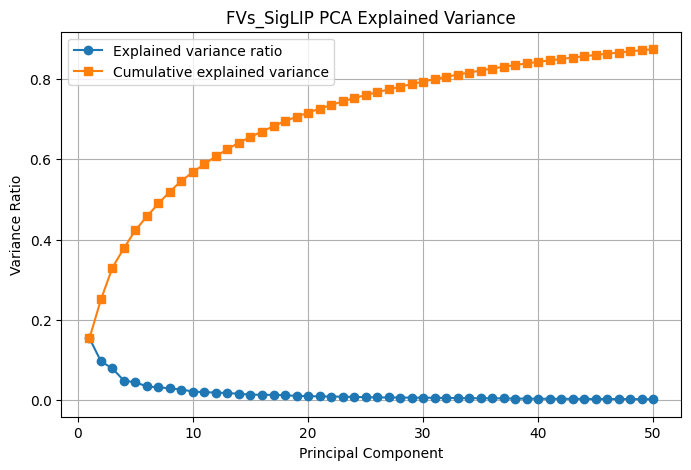

In [3]:
#医用基盤モデルの特徴空間には、少数の主要な方向により説明される構造が存在する。
explained = pca.explained_variance_ratio_
cum_explained = np.cumsum(explained)

plt.figure(figsize=(8, 5))
plt.plot(range(1, n_components + 1), explained, marker="o", label="Explained variance ratio")
plt.plot(range(1, n_components + 1), cum_explained, marker="s", label="Cumulative explained variance")
plt.xlabel("Principal Component")
plt.ylabel("Variance Ratio")
plt.title(f"{model_name} PCA Explained Variance")
plt.legend()
plt.grid(True)
plt.show()

将前十个打印出来看看

In [4]:
pca_df = meta_df.copy()

n_pcs_to_save = Z.shape[1] #50？

for i in range(n_pcs_to_save):
    pca_df[f"PC{i+1}"] = Z[:, i]

print(pca_df[["image_id", "patient_id", "eye", "eye_DR_Level", "PC1", "PC2", "PC3", "PC4", "PC5", "PC6", "PC7", "PC8", "PC9", "PC10"]].head())

  image_id  patient_id eye  eye_DR_Level       PC1        PC2        PC3  \
0     1_l1           1   l           0.0  3.514655 -10.731211  15.449586   
1     1_l2           1   l           0.0  9.406226  -2.402571   6.995405   
2     1_r1           1   r           0.0  4.802415  -8.795652   9.027819   
3     1_r2           1   r           0.0  9.687654  -0.835565   6.330733   
4     2_l1           2   l           2.0  8.379144   4.401083   4.140020   

        PC4        PC5       PC6       PC7       PC8       PC9      PC10  
0  1.285442  12.918219 -6.019680  3.506797 -8.600827  0.305306  3.724418  
1  2.906960   8.394377 -3.213206 -6.184459  0.896717 -1.815737 -3.616851  
2  9.613812   2.280176 -3.750641  0.406040 -6.227237 -0.694397  0.873322  
3  4.777236   4.375740 -3.374986 -2.550473 -4.917535 -2.578046 -3.652699  
4  2.183241  -5.837447  3.514800  8.835831  1.697247  3.363311  5.815368  


In [5]:
# 定义画图函数
def plot_pca_scatter(df, pc_x="PC1", pc_y="PC2", color_col="eye_DR_Level", title=None):
    plt.figure(figsize=(7, 6))
    
    labels = sorted(df[color_col].dropna().unique())
    
    for lab in labels:
        sub = df[df[color_col] == lab]
        plt.scatter(
            sub[pc_x],
            sub[pc_y],
            s=10,
            alpha=0.7,
            label=str(lab)
        )
    
    plt.xlabel(pc_x)
    plt.ylabel(pc_y)
    plt.title(title if title else f"{pc_x} vs {pc_y} colored by {color_col}")
    plt.legend(title=color_col, bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

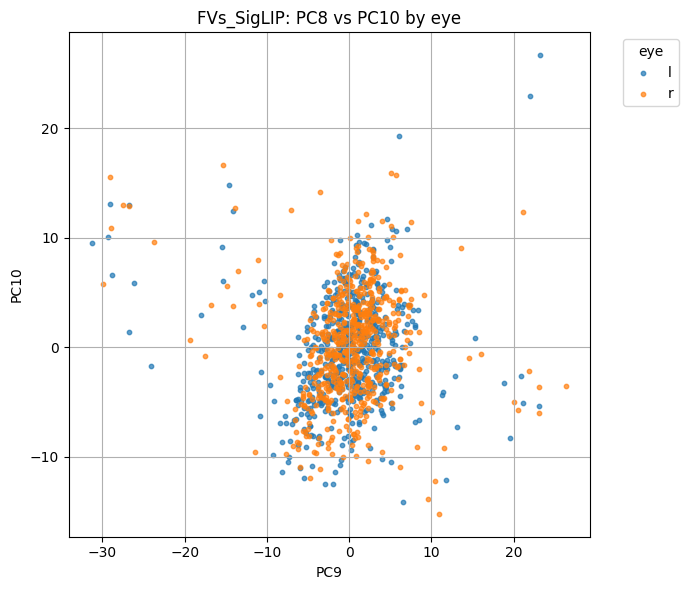

In [16]:
# 主成分1，2在各种成分上 的表现
# plot_pca_scatter(pca_df, "PC1", "PC2", "eye_DR_Level", f"{model_name}: PC1 vs PC2 by eye_DR_Level")
## plot_pca_scatter(pca_df, "PC2", "PC2", "eye", f"{model_name}: PC2 vs PC2 by eye")
### plot_pca_scatter(pca_df, "PC3", "PC3", "eye", f"{model_name}: PC3 vs PC3 by eye")
#### plot_pca_scatter(pca_df, "PC4", "PC4", "eye", f"{model_name}: PC4 vs PC4 by eye")
##### plot_pca_scatter(pca_df, "PC5", "PC5", "eye", f"{model_name}: PC5 vs PC5 by eye")
###### plot_pca_scatter(pca_df, "PC6", "PC6", "eye", f"{model_name}: PC6 vs PC6 by eye")
####### plot_pca_scatter(pca_df, "PC7", "PC7", "eye", f"{model_name}: PC7 vs PC7 by eye")
######## plot_pca_scatter(pca_df, "PC8", "PC8", "eye", f"{model_name}: PC8 vs PC8 by eye")
# plot_pca_scatter(pca_df, "PC8", "PC9", "eye", f"{model_name}: PC8 vs PC9 by eye")
plot_pca_scatter(pca_df, "PC9", "PC10", "eye", f"{model_name}: PC8 vs PC10 by eye")
# plot_pca_scatter(pca_df, "PC1", "PC2", "Overall quality", f"{model_name}: PC1 vs PC2 by Overall quality")
# plot_pca_scatter(pca_df, "PC1", "PC2", "Clarity", f"{model_name}: PC1 vs PC2 by Clarity")
# plot_pca_scatter(pca_df, "PC1", "PC2", "Field definition", f"{model_name}: PC1 vs PC2 by Field definition")
# plot_pca_scatter(pca_df, "PC1", "PC2", "Artifact", f"{model_name}: PC1 vs PC2 by Artifact")


In [19]:
from sklearn.metrics import roc_auc_score
import pandas as pd
import numpy as np

rows = []

for i in range(50):
    pc = f"PC{i+1}"
    tmp = pca_df[[pc, "eye"]].dropna()
    
    y = (tmp["eye"] == "r").astype(int)
    score = tmp[pc].values
    
    auc = roc_auc_score(y, score)
    auc = max(auc, 1 - auc)
    
    left_vals = tmp[tmp["eye"] == "l"][pc]
    right_vals = tmp[tmp["eye"] == "r"][pc]
    
    cohen_d = abs(left_vals.mean() - right_vals.mean()) / np.sqrt(
        (left_vals.var() + right_vals.var()) / 2
    )
    
    rows.append({
        "PC": pc,
        "eye_AUC": auc,
        "cohen_d": cohen_d,
        "explained_var": pca.explained_variance_ratio_[i],
    })

eye_pc_table = pd.DataFrame(rows).sort_values("eye_AUC", ascending=False)
eye_pc_table.head(20)

,PC,eye_AUC,cohen_d,explained_var
41,PC42,0.561294,0.203337,0.003567
2,PC3,0.558170,0.200344,0.079133
10,PC11,0.539204,0.112821,0.020091
39,PC40,0.538681,0.117335,0.003792
49,PC50,0.536293,0.095769,0.002571
33,PC34,0.535119,0.086564,0.005149
21,PC22,0.533277,0.085475,0.009342
26,PC27,0.532733,0.095733,0.006887
17,PC18,0.532731,0.117443,0.012589
43,PC44,0.530626,0.102942,0.003392


In [24]:
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import balanced_accuracy_score, roc_auc_score, accuracy_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# Strict fold-wise evaluation:
# PC1-k subspace eye prediction vs raw feature eye prediction
# ============================================================

# 标签
y_eye = (pca_df["eye"] == "r").astype(int).values
groups = pca_df["patient_id"].values

# 原始特征
X_input = X_raw

ks_requested = [10, 20, 50, 100, 200, 500]

# 实际可用的最大 PC 数
max_possible_k = min(
    max(ks_requested),
    X_input.shape[0] - 1,
    X_input.shape[1]
)

ks = [k for k in ks_requested if k <= max_possible_k]

print("X_input shape:", X_input.shape)
print("Evaluated PC subspaces:", ks)
print("Eye label distribution:")
print(pd.Series(y_eye).value_counts().sort_index())

X_input shape: (1189, 1152)
Evaluated PC subspaces: [10, 20, 50, 100, 200, 500]
Eye label distribution:
0    594
1    595
Name: count, dtype: int64


In [25]:
def make_eye_classifier():
    return LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        solver="lbfgs"
    )


def safe_auc(y_true, prob):
    if len(np.unique(y_true)) < 2:
        return np.nan
    return roc_auc_score(y_true, prob)


def calc_eye_metrics(y_true, pred, prob):
    return {
        "eye_accuracy": accuracy_score(y_true, pred),
        "eye_balanced_acc": balanced_accuracy_score(y_true, pred),
        "eye_AUC": safe_auc(y_true, prob)
    }

In [26]:
cv = GroupKFold(n_splits=5)

# out-of-fold prediction storage
pred_pc = {k: np.zeros_like(y_eye) for k in ks}
prob_pc = {k: np.zeros(len(y_eye), dtype=float) for k in ks}

pred_raw = np.zeros_like(y_eye)
prob_raw = np.zeros(len(y_eye), dtype=float)

fold_rows = []
cumvar_rows = []

for fold, (train_idx, test_idx) in enumerate(cv.split(X_input, y_eye, groups), start=1):
    
    print(f"Running fold {fold}...")
    
    X_train_raw = X_input[train_idx]
    X_test_raw = X_input[test_idx]
    
    y_train = y_eye[train_idx]
    y_test = y_eye[test_idx]
    
    # ========================================================
    # 1. X_raw baseline
    # ========================================================
    raw_clf = Pipeline([
        ("scaler", StandardScaler()),
        ("logreg", make_eye_classifier())
    ])
    
    raw_clf.fit(X_train_raw, y_train)
    
    pred_raw_fold = raw_clf.predict(X_test_raw)
    prob_raw_fold = raw_clf.predict_proba(X_test_raw)[:, 1]
    
    pred_raw[test_idx] = pred_raw_fold
    prob_raw[test_idx] = prob_raw_fold
    
    raw_metrics = calc_eye_metrics(y_test, pred_raw_fold, prob_raw_fold)
    raw_metrics.update({
        "fold": fold,
        "feature": "X_raw",
        "k": np.nan,
        "cum_explained_var": np.nan
    })
    fold_rows.append(raw_metrics)
    
    # ========================================================
    # 2. Fold-wise scaler for PCA
    # ========================================================
    scaler_fold = StandardScaler()
    X_train_std = scaler_fold.fit_transform(X_train_raw)
    X_test_std = scaler_fold.transform(X_test_raw)
    
    # 当前 fold 可用的最大 PCA 维度
    max_k_fold = min(
        max(ks),
        X_train_std.shape[0] - 1,
        X_train_std.shape[1]
    )
    
    pca_fold = PCA(
        n_components=max_k_fold,
        random_state=0
    )
    
    Z_train = pca_fold.fit_transform(X_train_std)
    Z_test = pca_fold.transform(X_test_std)
    
    cum_explained = np.cumsum(pca_fold.explained_variance_ratio_)
    
    # ========================================================
    # 3. PC1-k subspace linear probe
    # ========================================================
    for k in ks:
        if k > max_k_fold:
            continue
        
        pc_clf = Pipeline([
            ("scaler", StandardScaler()),
            ("logreg", make_eye_classifier())
        ])
        
        pc_clf.fit(Z_train[:, :k], y_train)
        
        pred_fold = pc_clf.predict(Z_test[:, :k])
        prob_fold = pc_clf.predict_proba(Z_test[:, :k])[:, 1]
        
        pred_pc[k][test_idx] = pred_fold
        prob_pc[k][test_idx] = prob_fold
        
        pc_metrics = calc_eye_metrics(y_test, pred_fold, prob_fold)
        pc_metrics.update({
            "fold": fold,
            "feature": f"PC1-{k}",
            "k": k,
            "cum_explained_var": cum_explained[k - 1]
        })
        fold_rows.append(pc_metrics)
        
        cumvar_rows.append({
            "fold": fold,
            "feature": f"PC1-{k}",
            "k": k,
            "cum_explained_var": cum_explained[k - 1]
        })

Running fold 1...
Running fold 2...
Running fold 3...
Running fold 4...
Running fold 5...


In [27]:
fold_results_df = pd.DataFrame(fold_rows)
fold_results_df

,eye_accuracy,eye_balanced_acc,eye_AUC,fold,feature,k,cum_explained_var
0,0.762500,0.762500,0.822014,1,X_raw,NaN,NaN
1,0.579167,0.579167,0.567014,1,PC1-10,10.0,0.572612
2,0.512500,0.512500,0.534583,1,PC1-20,20.0,0.718003
3,0.570833,0.570833,0.589028,1,PC1-50,50.0,0.877407
4,0.600000,0.600000,0.690764,1,PC1-100,100.0,0.946170
5,0.695833,0.695833,0.766528,1,PC1-200,200.0,0.982056
6,0.741667,0.741667,0.815208,1,PC1-500,500.0,0.999203
7,0.764706,0.764706,0.817951,2,X_raw,NaN,NaN
8,0.546218,0.546218,0.570864,2,PC1-10,10.0,0.566467
9,0.546218,0.546218,0.565709,2,PC1-20,20.0,0.721076


In [28]:
# fold-wise mean/std
summary_df = (
    fold_results_df
    .groupby("feature")[["eye_accuracy", "eye_balanced_acc", "eye_AUC", "cum_explained_var"]]
    .agg(["mean", "std"])
)

summary_df

eye_accuracy           eye_balanced_acc             eye_AUC            \
                mean       std             mean       std      mean       std   
feature                                                                         
PC1-10      0.558404  0.012639         0.558391  0.012640  0.563987  0.004868   
PC1-100     0.649442  0.051446         0.649476  0.051429  0.710846  0.048604   
PC1-20      0.545882  0.025708         0.545806  0.025636  0.566459  0.019191   
PC1-200     0.736002  0.032787         0.736026  0.032777  0.802030  0.030334   
PC1-50      0.584600  0.034824         0.584655  0.034744  0.607117  0.036645   
PC1-500     0.774698  0.029576         0.774661  0.029593  0.846962  0.047486   
X_raw       0.795714  0.030868         0.795699  0.030857  0.861397  0.038360   

        cum_explained_var            
                     mean       std  
feature                              
PC1-10           0.572788  0.005300  
PC1-100          0.946988  0.000666  
PC1-20           0.722273  0.003692  
PC1-200          0.982331  0.000257  
PC1-50           0.879521  0.001302  
PC1-500          0.999204  0.000012  
X_raw                 NaN       NaN

In [29]:
# pooled out-of-fold results
pooled_rows = []

for k in ks:
    metrics = calc_eye_metrics(y_eye, pred_pc[k], prob_pc[k])
    
    cumvar_mean = (
        fold_results_df[fold_results_df["feature"] == f"PC1-{k}"]["cum_explained_var"]
        .mean()
    )
    
    pooled_rows.append({
        "feature": f"PC1-{k}",
        "k": k,
        "eye_accuracy": metrics["eye_accuracy"],
        "eye_balanced_acc": metrics["eye_balanced_acc"],
        "eye_AUC": metrics["eye_AUC"],
        "cum_explained_var_mean": cumvar_mean
    })

raw_metrics = calc_eye_metrics(y_eye, pred_raw, prob_raw)

pooled_rows.append({
    "feature": "X_raw",
    "k": np.nan,
    "eye_accuracy": raw_metrics["eye_accuracy"],
    "eye_balanced_acc": raw_metrics["eye_balanced_acc"],
    "eye_AUC": raw_metrics["eye_AUC"],
    "cum_explained_var_mean": np.nan
})

pooled_results_df = pd.DataFrame(pooled_rows)
pooled_results_df

,feature,k,eye_accuracy,eye_balanced_acc,eye_AUC,cum_explained_var_mean
0,PC1-10,10.0,0.558452,0.558456,0.564465,0.572788
1,PC1-20,20.0,0.545837,0.545811,0.567199,0.722273
2,PC1-50,50.0,0.584525,0.584529,0.606652,0.879521
3,PC1-100,100.0,0.649285,0.649301,0.710107,0.946988
4,PC1-200,200.0,0.735913,0.735921,0.801047,0.982331
5,PC1-500,500.0,0.774601,0.774598,0.845636,0.999204
6,X_raw,NaN,0.795627,0.795630,0.861927,NaN


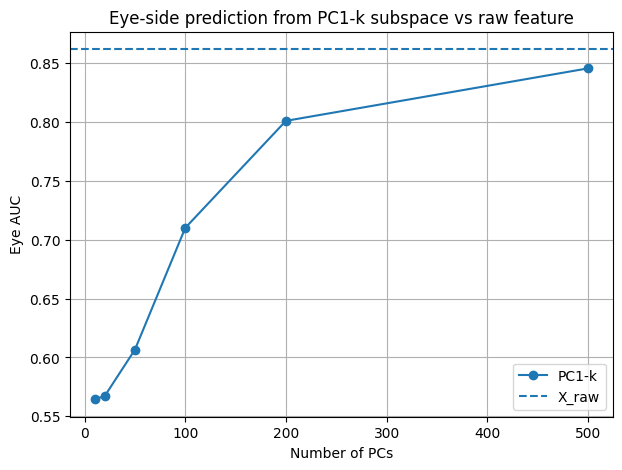

In [30]:
plot_df = pooled_results_df[pooled_results_df["feature"].str.startswith("PC1-")].copy()
raw_auc = pooled_results_df.loc[pooled_results_df["feature"] == "X_raw", "eye_AUC"].iloc[0]

plt.figure(figsize=(7, 5))
plt.plot(plot_df["k"], plot_df["eye_AUC"], marker="o", label="PC1-k")
plt.axhline(raw_auc, linestyle="--", label="X_raw")

plt.xlabel("Number of PCs")
plt.ylabel("Eye AUC")
plt.title("Eye-side prediction from PC1-k subspace vs raw feature")
plt.grid(True)
plt.legend()
plt.show()

与 MedSigLIP 不同，SigLIP 的上位主成分中没有发现能够单独区分左右眼的主成分。single-PC 分析中最高 eye AUC 仅为 0.561，PC1–50 子空间的 eye AUC 也仅为 0.607。另一方面，随着使用的主成分数量增加，eye AUC 逐渐上升，PC1–200 达到 0.801，PC1–500 达到 0.846，接近原始特征 X_raw 的 0.862。该结果表明，SigLIP 特征空间中确实包含左右眼信息，但该信息并未集中在主导方差方向上，而是分散存在于大量低方差主成分构成的高维子空间中。

MedSigLIP とは異なり、SigLIP では左右眼を単独で明確に分離する主成分は確認されなかった。single-PC 解析における最大 eye AUC は 0.561 にとどまり、PC1–50 の部分空間を用いた場合でも eye AUC は 0.607 であった。一方で、使用する主成分数を増やすにつれて eye AUC は上昇し、PC1–200 では 0.801、PC1–500 では 0.846 に達し、原特徴量 X_raw を用いた場合の 0.862 に近づいた。この結果から、SigLIP の特徴空間には左右眼情報が存在するものの、それは主要な分散方向には集中しておらず、多数の低分散主成分からなる高次元部分空間に分散して表現されていることが示唆された。

In [5]:
from sklearn.metrics import roc_auc_score
from scipy.stats import spearmanr
import pandas as pd
import numpy as np

GRADE_COL = "patient_DR_Level"   # 这里改成你自己的病变等级列名，例如 "DR_grade"
N_PC = 50

def safe_auc(y_binary, score):
    """
    计算二分类AUC。
    如果只有一个类别，返回 NaN。
    因为PC方向正负是任意的，所以取 max(AUC, 1-AUC)。
    """
    y_binary = np.asarray(y_binary)
    score = np.asarray(score)

    if len(np.unique(y_binary)) < 2:
        return np.nan

    auc = roc_auc_score(y_binary, score)
    return max(auc, 1 - auc)


rows = []

for i in range(N_PC):
    pc = f"PC{i+1}"

    tmp = pca_df[[pc, GRADE_COL]].dropna()

    y_grade = tmp[GRADE_COL].astype(int)
    score = tmp[pc].values

    # 1. 等级与PC的单调相关性
    spearman_r, spearman_p = spearmanr(y_grade, score)

    # PC方向任意，所以相关系数也建议看绝对值
    spearman_abs = abs(spearman_r)

    # 2. 多个临床阈值下的AUC
    # grade >= 1 : 是否有病变
    # grade >= 2 : 是否中度及以上
    # grade >= 3 : 是否重度及以上
    # grade >= 4 : 是否PDR
    auc_ge_1 = safe_auc(y_grade >= 1, score)
    auc_ge_2 = safe_auc(y_grade >= 2, score)
    auc_ge_3 = safe_auc(y_grade >= 3, score)
    auc_ge_4 = safe_auc(y_grade >= 4, score)

    auc_list = [auc_ge_1, auc_ge_2, auc_ge_3, auc_ge_4]
    mean_threshold_auc = np.nanmean(auc_list)

    rows.append({
        "PC": pc,
        "grade_spearman_abs": spearman_abs,
        "grade_spearman": spearman_r,
        "grade_spearman_p": spearman_p,
        "AUC_grade>=1": auc_ge_1,
        "AUC_grade>=2": auc_ge_2,
        "AUC_grade>=3": auc_ge_3,
        "AUC_grade>=4": auc_ge_4,
        "mean_grade_AUC": mean_threshold_auc,
        "explained_var": pca.explained_variance_ratio_[i],
    })

grade_pc_table = pd.DataFrame(rows).sort_values(
    "mean_grade_AUC", ascending=False
)

grade_pc_table.head(20)

,PC,grade_spearman_abs,grade_spearman,grade_spearman_p,AUC_grade>=1,AUC_grade>=2,AUC_grade>=3,AUC_grade>=4,mean_grade_AUC,explained_var
0,PC1,0.644778,-0.644778,1.086364e-140,0.824807,0.818988,0.866777,0.787847,0.824605,0.154283
1,PC2,0.290719,-0.290719,1.369518e-24,0.535729,0.661913,0.760099,0.689437,0.661795,0.096729
8,PC9,0.321484,0.321484,5.439199e-30,0.728713,0.660818,0.601752,0.635500,0.656696,0.026660
5,PC6,0.311807,-0.311807,3.192759e-28,0.710974,0.670464,0.620755,0.551489,0.638420,0.034249
6,PC7,0.265567,0.265567,1.215074e-20,0.703509,0.610809,0.602986,0.578679,0.623996,0.032129
4,PC5,0.228950,-0.228950,1.319949e-15,0.661771,0.608234,0.562525,0.654326,0.621714,0.044764
2,PC3,0.207702,-0.207702,4.708553e-13,0.686149,0.595980,0.557613,0.503461,0.585801,0.079133
12,PC13,0.137636,0.137636,1.901346e-06,0.566216,0.596458,0.555546,0.540154,0.564594,0.017913
40,PC41,0.132146,0.132146,4.833099e-06,0.548894,0.592432,0.576397,0.523394,0.560279,0.003662
22,PC23,0.039168,0.039168,1.771133e-01,0.526051,0.507224,0.547216,0.657640,0.559533,0.008835
